# Big Data Analytics Homework 04

*Complete this assignment in Google Colab. Prior to submitting a copy of this notebook (.ipynb format), run every cell and ensure you have corrected all runtime errors. Be sure to fill in your Name and SUID in the following cell. As always, you must do your own work. This means you may not use answers to the following questions generated by any other person or a generative AI tool such as ChatGPT. You may, however, discuss this assignment with others in a general way and seek help when you need it, but, again, you must do your own work.*

Name: Kent Roller

SUID:kdroller

### Setup

In [1]:
! pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession
from pyspark import SparkContext

sc = SparkContext.getOrCreate()

spark = SparkSession\
    .builder\
    .appName('Homework 04')\
    .getOrCreate()

This assignment uses a data set containing information about data science programs at universities worldwide.

The dataset contains many columns that we can use to understand how these data science programs differ from one another.

In [3]:
# download the data scince programs data set
%%bash
if [[ ! -f colleges-data-science-programs.csv ]]; then
 wget https://syr-bda.s3.us-east-2.amazonaws.com/colleges-data-science-programs.csv -q
fi

### Q1

Read `colleges-data-science-programs.csv` into a Spark data frame named `raw_ds_programs_text`.

In [4]:
# your code here
#Use sparks built in csv reader to read in csv file, pull header and schema from document on import
raw_ds_programs_text = spark.read.csv("colleges-data-science-programs.csv", header=True, inferSchema=True)


In [5]:
# do not modify
print('rows: ', raw_ds_programs_text.count(),
      ', cols:', len(raw_ds_programs_text.columns))

raw_ds_programs_text\
  .show(5)

rows:  222 , cols: 28
+---+--------------------+--------------------+--------------------+-------+-------+-----+------+--------+--------------------+-------------------+-------------------+----------------+------------+-------+----------+------------+-----+----+-------------+----------------+--------+---------+--------------------+--------+---------+---------+------+
| id|                name|                 url|             program| degree|country|state|online|oncampus|          department|         created_at|         updated_at|university_count|program_size|courses|admit_reqs|year_founded|notes|cost|visualization|machine learning|business|databases|programminglanguages|capstone|mapreduce|part-time|ethics|
+---+--------------------+--------------------+--------------------+-------+-------+-----+------+--------+--------------------+-------------------+-------------------+----------------+------------+-------+----------+------------+-----+----+-------------+----------------+--------+--

### Q2

Starting with `raw_ds_programs_text`, create a new data frame named `ds_programs_text` which simply adds a column named `text` to the original data frame.

The `text` column will be a concatenation of the following columns, separated by a space: `program`, `degree`, and `department`. You eill find the appropriate function in `pyspark.sql.functions`

An example of the `ds_programs_text_df` should give you:

```python
ds_programs_text.orderBy('id').first().text
```

```console
'Data Science Masters Mathematics and Statistics'
```

In [6]:
from typing import Concatenate
from pyspark.sql.functions import concat, lit
# your code here
#Create new df with additional column
#Call concat function to pull in columns of interest into new column
#Had to use sql functions as ran into issues with typing function
#Unsure of the issue at this time
ds_programs_text = raw_ds_programs_text.withColumn("text",
                                                   concat(
                                                       raw_ds_programs_text["program"],
                                                       lit(" "),
                                                       raw_ds_programs_text["degree"],
                                                       lit(" "),
                                                       raw_ds_programs_text["department"]
                                                   )

                                                   )

In [7]:
# do not modify
ds_programs_text.select('text')\
  .show(5, truncate = False)

+------------------------------------------------------------------+
|text                                                              |
+------------------------------------------------------------------+
|Data Science Masters Mathematics and Statistics                   |
|Analytics Masters Business and Information Systems                |
|Data Science Masters Computer Science                             |
|Business Intelligence & Analytics Masters Business                |
|Advanced Computer Science(Data Analytics) Masters Computer Science|
+------------------------------------------------------------------+
only showing top 5 rows



### Q3

Create a pipeline named `pipe_features` that creates a new dataframe `ds_features`. The `pipe_features` pipeline should add a column, `features` to `ds_programs_text` that contains the `tfidf` of the `text` column.

Make sure to create your pipeline using methodology similar to what was demonstrated in class. Aside from removing stop words and setting a minumum token length of 2, no further restrictions should be imposed on the resulting vocabulary.

In [8]:
from pickle import FALSE
# your code here
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline
import requests

#Set up tokenizer
# Set min token length to 2 as specified above
tokenize = RegexTokenizer(minTokenLength= 2)\
  .setGaps(False)\
  .setPattern('[a-zA-Z]+')\
  .setInputCol('text') \
  .setOutputCol('words')

#Remove stop words
#Use url of stop word bag to use instead of manually declaring
stop_words=requests.get('http://ir.dcs.gla.ac.uk/resources/linguistic_utils/stop_words')\
  .text\
  .split()

#Declare function for stages to use to remove stop words in pipeline
remove_sw = StopWordsRemover()\
  .setStopWords(stop_words)\
  .setCaseSensitive(False)\
  .setInputCol('words')\
  .setOutputCol("filtered")

#Initialize the count vectorizer
cv=CountVectorizer(inputCol= "filtered",
                   outputCol="tf")

#Compute the inverse frequency
idf = IDF (inputCol= "tf",
           outputCol="features")

#create the pipeline utilizing methods declared above
pipeline = Pipeline()\
    .setStages([tokenize,
                remove_sw,
                cv,
                idf])

#Clean column of nulls to allow for automated processing
clean_ds_text = ds_programs_text.filter(ds_programs_text.text.isNotNull())

#Apply pipeline to cleaned text data
ds_features = pipeline.fit(clean_ds_text).transform(clean_ds_text)

#use the pipeline on the dataset
#Ran into an error when trying to use this code before cleaning the text column
#Once implemented the cleaned text column appeared to resolve the issue
#ds_features = pipeline.fit(ds_programs_text).transform(ds_programs_text)



In [9]:
# do not modify
ds_features.select('features')\
  .show(5,
        truncate = False)

+-------------------------------------------------------------------------------------------------------------------+
|features                                                                                                           |
+-------------------------------------------------------------------------------------------------------------------+
|(74,[0,2,4,6,24],[0.39053945789148875,0.7006943861953282,1.0402015265116953,2.1177604059819726,3.0985896589936988])|
|(74,[0,1,3,5,22],[0.39053945789148875,1.0402015265116953,0.6276692511804384,2.0571357841655376,2.9444389791664403])|
|(74,[0,2,4],[0.39053945789148875,0.7006943861953282,2.0804030530233906])                                           |
|(74,[0,1,3,26],[0.39053945789148875,2.0804030530233906,0.6276692511804384,3.2809112157876537])                     |
|(74,[0,2,3,4,31],[0.39053945789148875,0.7006943861953282,0.6276692511804384,2.0804030530233906,3.5040547671018634])|
+-------------------------------------------------------

### Q4

Create a pipeline model called `pipe_pca` that computes the first two principle components of the `features` column created by `pipe_features`, and creates a new column named `scores`.

Use `pipe_pca` to create a data frame, `ds_features_1` with the columns `id`, `name`, `url`, and `scores`.

Note: Prior to computing PCA scores, you will want to scale the TF-IDF outputs. Refer to lecture notes regarding the appropriate parameters to use during this step.

In [10]:
# your code here
from pyspark.ml import feature
#Create pipeline for PCA

#Need to create scalar to scale the tf-idf outputs as requested
center = feature.StandardScaler(withMean=True,
                                withStd = False,
                                inputCol="features",
                                outputCol="centered_tfidf")

#Initilaize PCA stage
#Set limit of number of principle components to be learned to
pca = feature.PCA(k=2,
                  inputCol='centered_tfidf',
                  outputCol='scores')

#Create new pipeline called pipe_pca and utilize center and pca
pipe_pca = Pipeline(stages= [center, pca])

#Apply created pipe to calculate PCA and create new df as requested
ds_features_1 = pipe_pca.fit(ds_features).transform(ds_features)

#Pull out desired columns
ds_features_1 = ds_features_1.select("id", "name", "url", "scores")



In [11]:
# do not modify
ds_features_1\
  .select('scores')\
  .show(5,
        truncate = False)

+------------------------------------------+
|scores                                    |
+------------------------------------------+
|[0.46446050750780193,0.8249659423761466]  |
|[0.48331270431312645,0.8434656014380466]  |
|[0.19887398141287316,-0.20010423434914978]|
|[0.752298549412132,-0.9291474395224366]   |
|[0.2881403236065434,-0.3448287697502237]  |
+------------------------------------------+
only showing top 5 rows



### Q5

In this question you will write code that makes recommendations for programs closest to a program of interest.  

Create a function named `get_nearest_programs` that returns the 3 closest programs to a program of interest.

The `get_nearest_programs` function should take 1 argument: `program_of_interest`. Write the function so that it returns the 3 programs (as defined by the `name` column) closest to the program argument as defined by Euclidian (L2) distance. Do not return the program of interest as one of the names.

Your function should **not** consider **Bachelors** programs.

In [12]:
# your code here
from pyspark.sql import Row
from pyspark.sql.functions import col, lit
import numpy as np
from pyspark.ml.linalg import Vectors

def get_nearest_programs(program_of_interest):
  '''
  This function returns the 3 closest programs to a given program by calculating
  the distance between the PCA scores of the selected program to the rest of programs
  '''

  #Get the PCA scores and name for the program of interest
  program_row = ds_features_1.filter(col("name")== program_of_interest).select("name", "scores").collect()
  program_pca = np.array(program_row[0]["scores"])

  #Calculate distance from the program entered to all other programs
  def compute_distance(row):
    return Row(
        name=row["name"],
        url=row["url"],
        distance=float(np.linalg.norm(np.array(row["scores"])-program_pca))
      )
  distances_df = ds_features_1.rdd.map(lambda row: compute_distance(row)).toDF()

  #Exclude the program entered and only include 3 closest programs in the df
  nearest_programs = (
      distances_df.filter(col("name") != program_of_interest)
      .orderBy(col("distance").asc())
      .limit(3)
  )

  #Return the 3 nearest programs from the filter
  return nearest_programs.select("name","distance").collect()

In [13]:
# do not modify
get_nearest_programs('Syracuse University')

[Row(name='South Dakota State University', distance=0.25049944953656966),
 Row(name='TU Dortmund', distance=0.27003983220544386),
 Row(name='Dakota State University', distance=0.27642307826592916)]

### Q6

Create two Pandas dataframes `pc1` and `pc2` with the columns `word` and `absolute_loading` that contain the top 5 absolute values (descending order) of loadings.

In [14]:
# your code here
import pandas as pd

fitted_pipeline = pipeline.fit(clean_ds_text)
fitted_pca_pipeline=pipe_pca.fit(ds_features)

#Extarct PCA model from the pipeline to use for df pc1 and pc2
pca_model = fitted_pca_pipeline.stages[-1]

#Pull the count vectorizor
cv_model = fitted_pipeline.stages[2]

#Get the PCA loadings
loadings = np.array(pca_model.pc.toArray())

#Get the vocabulary from the cv_model
vocab = cv_model.vocabulary

#Function to create a DF for PCA
def create_loading_df(component_index):
  component_loadings = loadings[:, component_index]
  absolute_loadings = np.abs(component_loadings)
  #Make df
  df=pd.DataFrame({
      "word" : vocab,
      "absolute_loading" : absolute_loadings
  })

  #Sort by absolute loadigns
  df = df.sort_values(by="absolute_loading", ascending=False).head(5)

  #return the df
  return df

#Create the pc1 and pc2 df
pc1=create_loading_df(0)
pc2=create_loading_df(1)


In [15]:
#Had issues with calling the correct stage, using this to
#print the stages and their stage number so can be called correctly above
for i, stage in enumerate(fitted_pipeline.stages):
    print(f"Stage {i}: {type(stage)}")

Stage 0: <class 'pyspark.ml.feature.RegexTokenizer'>
Stage 1: <class 'pyspark.ml.feature.StopWordsRemover'>
Stage 2: <class 'pyspark.ml.feature.CountVectorizerModel'>
Stage 3: <class 'pyspark.ml.feature.IDFModel'>


In [16]:
# do not modify
display(pc1.head())
display(pc2.head())

,word,absolute_loading
15,computational,0.607456
9,sciences,0.473206
30,physics,0.321330
27,astronomy,0.321330
12,school,0.268473


,word,absolute_loading
16,computing,0.497220
5,information,0.408192
6,statistics,0.309746
11,doctorate,0.297964
19,informatics,0.272927


### Q7

Create a new pipeline called `pipe_pca_1` where you fit the maximum possible number of principal components for this dataset.

Create a scree plot and a plot of cumulative variance explained (exactly 2 plots).

Answer the following:

1. How many principal components were able to create (the maximum number)?

2. Based on either the scree or cumulative variance explained plot, how many principal components would you use if you were building a supervised machine learning model, and why?

In [33]:
# your code for new pipeline here

#double check dimensionality to ensure max number of components is selected
num_features = ds_features.select("features").head()[0].size

#Create PCA stage with max number of components calling num features to set k
pca_max = feature.PCA(k=num_features, inputCol="centered_tfidf", outputCol="scores_all")

#Create a new pipeline
pipe_pca_1 = Pipeline(stages=[center, pca_max])

#fit the pipeline to the data
fitted_pipe_pca_1 = pipe_pca_1.fit(ds_features)

#Apply the pipeline transformation
ds_features_max_pca = fitted_pipe_pca_1.transform(ds_features)

#Access the PCA model to extract the information
pca_model_max=fitted_pipe_pca_1.stages[-1]
explained_variance = np.array(pca_model_max.explainedVariance.toArray())

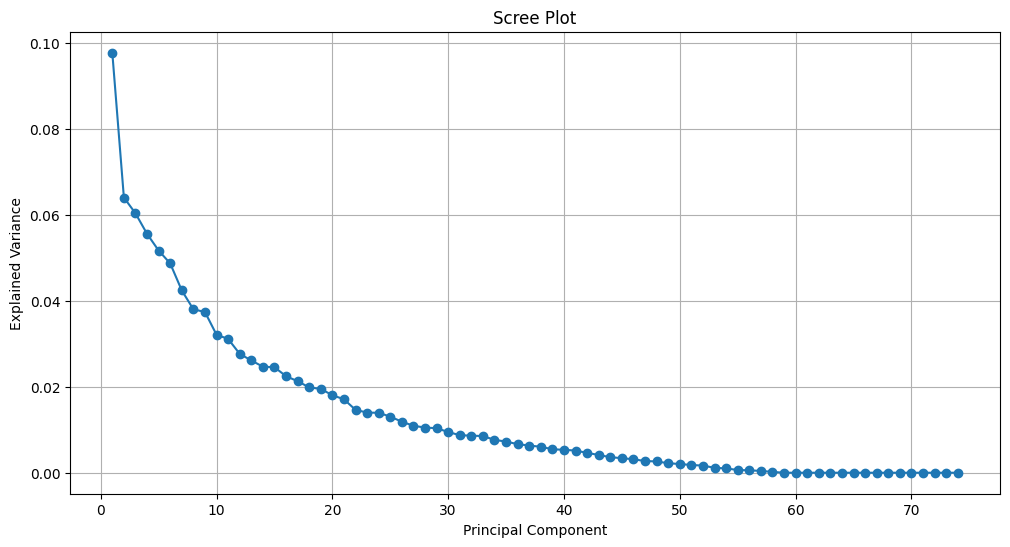

In [34]:
# your code for scree plot here
import matplotlib.pyplot as plt
#Specify plt size to increase readability and prevent points from being buncehd up
plt.figure(figsize=(12, 6))
#Set line to length of observations in explained_variance and specify marker type for plt
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-')
#Add plt title and labels
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
#Add grid to plt
plt.grid()
#Print plt
plt.show()


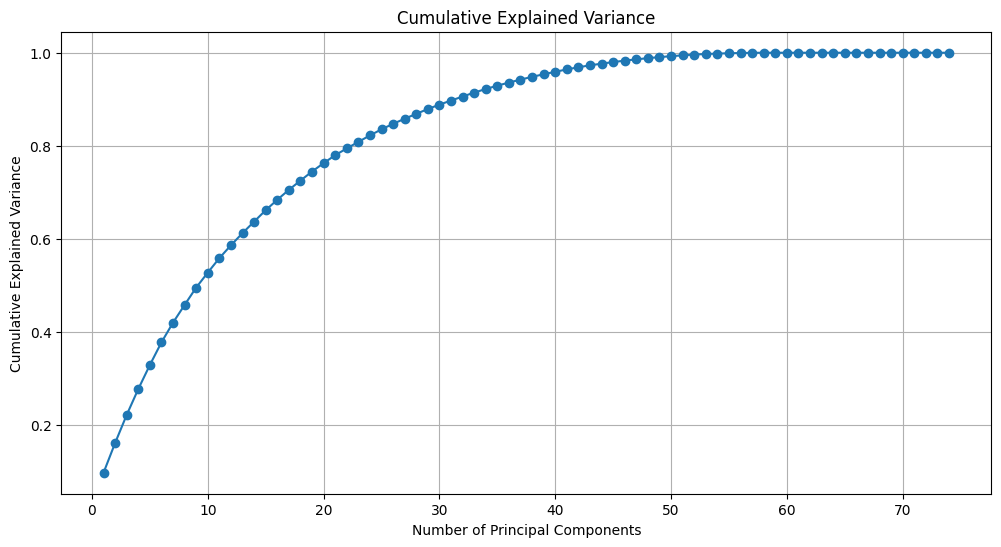

In [31]:
# your code for cumulative variance explained plot here

#Specify plot size to prevent points from being bunched together
plt.figure(figsize=(12, 6))
#Use built in cumsum function found in np to make plt
cumulative_variance = np.cumsum(explained_variance)
#Set length of line to lenght of observatiosn and specify marker type
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
#add title and labels
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
#Add grid to plt for clarity and readabilty
plt.grid()
#Print plot
plt.show()

*your answers here*
Looking at the Scree plot, it can be observed that the first component explains a very large amount of the variance in the data. The next 9 also explain a relatively large amount of the variance, but drops quickly. Moving up to 20 components covers a large amount of variance in the data.Moving beyond 30 components has rapidly diminishing returns and as such would not move beyond 30 components for any model. For the purposes of model creation based on the output of the scree plot would choose between 20-30 components for the initial pass of models and then compare via performance/accuracy metrics to make a determination of which number to stick with.


### Q8

Starting with `pipe_pca_1` from the previous question, transform the pipeline and save the resulting dataframe to a variable named `pca_fun`.  

Extract the output from the standard scaler column from the first row of `pca_fun` and store in a variable named `row1_centered`.

Manually compute 5 PCA scores by projecting `row1_centered` onto the first 5 loading vectors which were computed in your PCA object. Save the 5 projected pca scores in a varialbe called `proj_scores`.

Extract the first 5 PCA scores from the first row of the pca_fun scores column and save them in a variable named `pca_fun_scores`.

In [21]:
# your answer here

#Transform the dataset and store in pca_fun
pca_fun = fitted_pipe_pca_1.transform(ds_features)

#Extract the output from the StandardScalar column for the first row
row1_centered = np.array(pca_fun.select("centered_tfidf").head()[0].toArray())

#Extract the PCA loadings from the PCA model
pca_model_max = fitted_pipe_pca_1.stages[-1]
loadings_first_5 = np.array(pca_model_max.pc.toArray())[:, :5]

#Manually calculate 5 PCA scores by projecting row1 onto the first five loadings
proj_scores = row1_centered @ loadings_first_5

#Extract the first 5 pca scores from the df
pca_fun_scores = np.array(pca_fun.select("scores_all").head()[0][:5])


In [22]:
# do not modify
print(proj_scores)
print(pca_fun_scores)

[ 0.46446051  0.82496594 -0.90092054  0.82462029  1.51787419]
[ 0.46446051  0.82496594 -0.90092054  0.82462029  1.51787419]


### Q9

Perform an **inverse transform** on the `proj_scores` variable and store the result in a variable named `inverse`.

The grading cell below prints `inverse` and the original `row1_centered` data such that they are right next to each other.

If `inverse` is different than `row1_centered`, explain why. How you could modify the forward and reverse transformation process such that the resulting `inverse` data almost exactly matches `row1_centered`.

In [23]:
# your code here

#Perform inverse transform on proj_scores (PCA scores) and the first five loadings
inverse = np.dot(proj_scores, loadings_first_5.T)

*your answer here*
The data doesnt align perfectly because we limited the number of components in the loadings variable to 5 which reduced the amount of varibality in the data and reduced the accuracy. For the two values to be aligned the loadings line needs to be modified to include all components so that the loadings are more representative/accurate.

In [24]:
# do not modify
print(row1_centered[0:5])
print(inverse[0:5])

[ 0.12722119 -0.59102359  0.31849745 -0.33760998  0.54374171]
[-0.03228328 -0.88301126  0.28606038 -0.24907343  0.38483599]


### Q10

Implement your modification so that `row1_centered` and `inverse` match almost exactly.

In [25]:
# your code here
#Modify the loadings section to include all values instead of cutting at 5 components
loadings_full = np.array(pca_model_max.pc.toArray())
#Make sure that row1_centered is fit to the full stack of components vs 5 as before
scores_full = row1_centered @ loadings_full

#Reinitialize the inverse variable to call on the updated loadings variable and the
# two rows should be aligned.
inverse = np.dot(scores_full, loadings_full.T)

In [26]:
# do not modify
print(row1_centered[0:5])
print(inverse[0:5])

[ 0.12722119 -0.59102359  0.31849745 -0.33760998  0.54374171]
[ 0.12722119 -0.59102359  0.31849745 -0.33760998  0.54374171]
